<a href="https://colab.research.google.com/github/laboratoriodecodigos/Colab-Python/blob/main/MLP_Regresi%C3%B3n_Dataset_Diabetes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Features: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
Forma de X: (442, 10) | Forma de y: (442,)

--- Métricas en test ---
MSE:  2955.42
RMSE: 54.36
MAE:  44.31
R²:   0.4422
Iteraciones hasta converger: 267

Gráfica guardada en: resultados_mlp_regresion.png


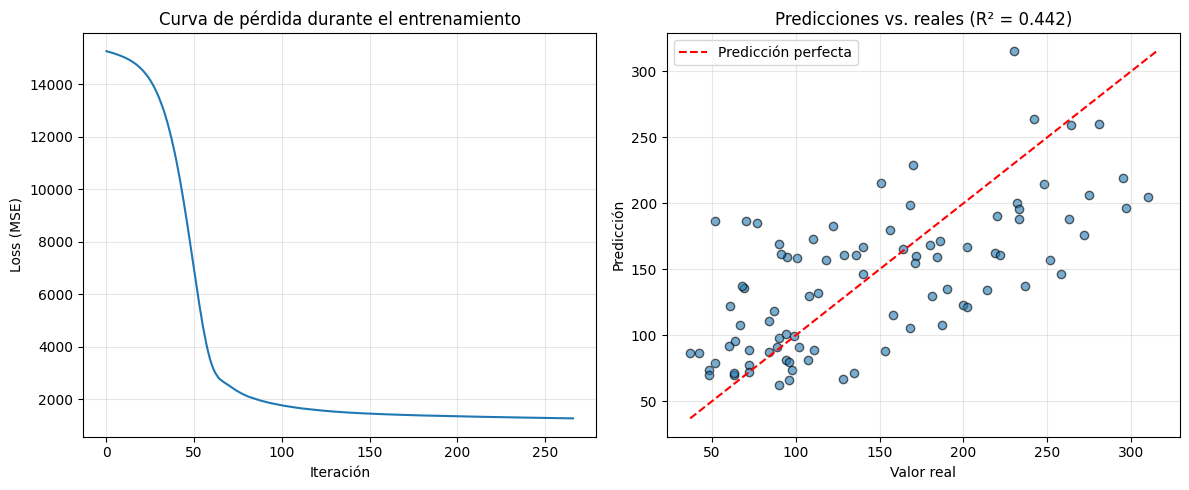

In [1]:
"""
MLP (Perceptrón Multicapa) para Regresión
Dataset: Diabetes (sklearn) — predice la progresión de la enfermedad
a partir de 10 variables clínicas (edad, sexo, IMC, presión, etc.)
"""

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. Cargar dataset (442 pacientes, 10 features, target continuo)

data = load_diabetes()
X, y = data.data, data.target
print("Features:", data.feature_names)
print("Forma de X:", X.shape, "| Forma de y:", y.shape)


# 2. Train / test split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. Escalado

scaler_X = StandardScaler()
X_train_s = scaler_X.fit_transform(X_train)
X_test_s = scaler_X.transform(X_test)


# 4. Definir y entrenar el MLP

mlp = MLPRegressor(
    hidden_layer_sizes=(64, 32, 16),   # 3 capas ocultas
    activation="relu",
    solver="adam",
    alpha=1e-3,                        # regularización L2
    learning_rate_init=0.001,
    max_iter=2000,
    early_stopping=True,               # usa validación interna para detener a tiempo
    n_iter_no_change=20,
    random_state=42,
)

mlp.fit(X_train_s, y_train)


# 5. Evaluación

y_pred = mlp.predict(X_test_s)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n--- Métricas en test ---")
print(f"MSE:  {mse:.2f}")
print(f"RMSE: {np.sqrt(mse):.2f}")
print(f"MAE:  {mae:.2f}")
print(f"R²:   {r2:.4f}")
print(f"Iteraciones hasta converger: {mlp.n_iter_}")

# -----------------------------------------------------------------
# 6. Gráficas: curva de pérdida + predicciones vs valores reales
# -----------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(mlp.loss_curve_)
axes[0].set_xlabel("Iteración")
axes[0].set_ylabel("Loss (MSE)")
axes[0].set_title("Curva de pérdida durante el entrenamiento")
axes[0].grid(alpha=0.3)

axes[1].scatter(y_test, y_pred, alpha=0.6, edgecolor="k")
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[1].plot(lims, lims, "r--", label="Predicción perfecta")
axes[1].set_xlabel("Valor real")
axes[1].set_ylabel("Predicción")
axes[1].set_title(f"Predicciones vs. reales (R² = {r2:.3f})")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("resultados_mlp_regresion.png", dpi=150)
print("\nGráfica guardada en: resultados_mlp_regresion.png")
